In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC, SVR, LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', version=1)

X, y = mnist.data, mnist.target

In [2]:
print(mnist.DESCR)

**Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  
**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  
**Please cite**:  

The MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  

It is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain grey levels as a result of the anti-aliasing technique used by the normalization algorithm. the images were centered in a 28x28 image b

In [ ]:
n = X.iloc[0]
for i in n:
    print(i)


0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
3
18
18
18
126
136
175
26
166
255
247
127
0
0
0
0
0
0
0
0
0
0
0
0
30
36
94
154
170
253
253
253
253
253
225
172
253
242
195
64
0
0
0
0
0
0
0
0
0
0
0
49
238
253
253
253
253
253
253
253
253
251
93
82
82
56
39
0
0
0
0
0
0
0
0
0
0
0
0
18
219
253
253
253
253
253
198
182
247
241
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
80
156
107
253
253
205
11
0
43
154
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
14
1
154
253
90
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
139
253
190
2
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
11
190
253
70
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
35
241
225
160
108
1
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
81
240
253
253
119
25
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0

In [ ]:
X.iloc[0]     # 28 * 28 = 784

pixel1      0
pixel2      0
pixel3      0
pixel4      0
pixel5      0
           ..
pixel780    0
pixel781    0
pixel782    0
pixel783    0
pixel784    0
Name: 0, Length: 784, dtype: int64

In [ ]:
from PIL import Image
import numpy as np

img = Image.open("/kaggle/input/datasets/haseebekhan/simple-image/20260502_0019.jpeg").convert('RGB')
img_array = np.array(img)


In [ ]:
print(img_array)

[[[ 10  10  12]
  [ 12  12  14]
  [ 16  16  18]
  ...
  [110 122 146]
  [112 124 150]
  [112 124 150]]

 [[ 10  10  12]
  [ 12  12  14]
  [ 15  15  17]
  ...
  [108 120 144]
  [110 122 148]
  [111 123 149]]

 [[  8   8  10]
  [  9   9  11]
  [ 11  11  13]
  ...
  [105 117 143]
  [108 120 146]
  [110 122 148]]

 ...

 [[ 19  31  29]
  [ 12  24  22]
  [  5  17  15]
  ...
  [ 34  45  39]
  [ 36  47  41]
  [ 37  48  42]]

 [[ 11  23  21]
  [  8  20  18]
  [  4  16  14]
  ...
  [ 33  44  38]
  [ 34  45  39]
  [ 35  46  40]]

 [[  4  16  14]
  [  5  17  15]
  [  5  17  15]
  ...
  [ 31  42  36]
  [ 32  43  37]
  [ 33  44  38]]]


In [ ]:
R = img_array[:, :, 0]
G = img_array[:, :, 1]
B = img_array[:, :, 2]

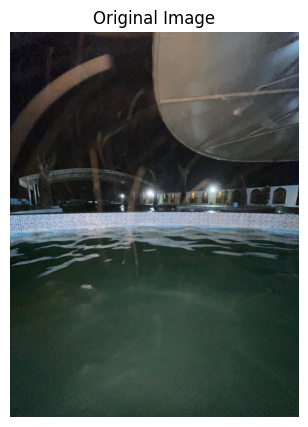

In [ ]:

# 3. Display the original image
plt.figure(figsize=(5, 5))
plt.imshow(img_array)
plt.title("Original Image")
plt.axis("off")
plt.show()


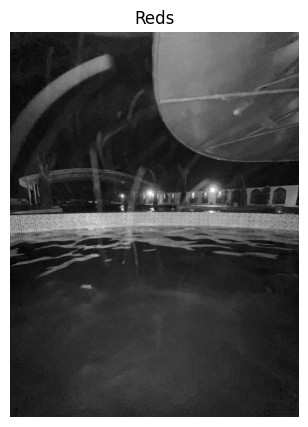

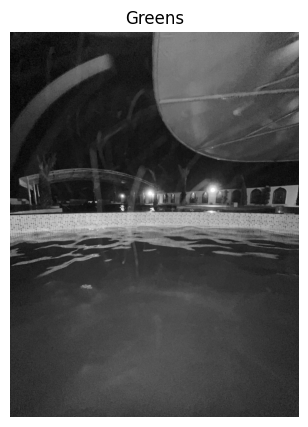

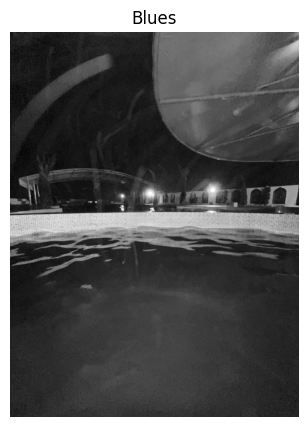

In [ ]:
channels = [R, G, B]
titles = ["Reds", "Greens", "Blues"]

for channel, title in zip(channels, titles):
    plt.figure(figsize=(5, 5))
    plt.imshow(channel, cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()

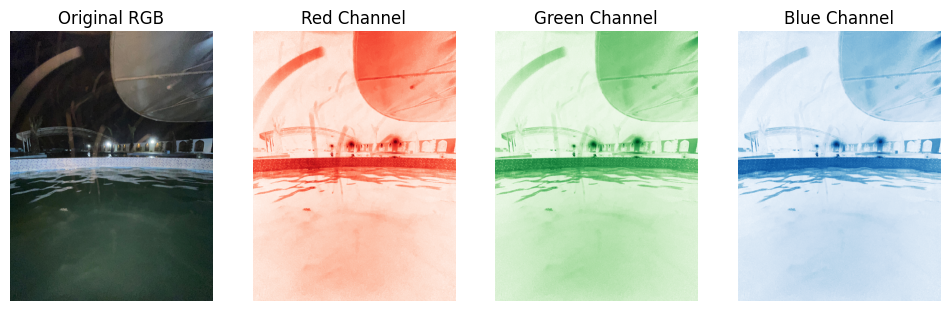

In [ ]:
import matplotlib.pyplot as plt

# Method 1: Using matplotlib
fig, axes = plt.subplots(1, 4, figsize=(12, 4))

# Original image
axes[0].imshow(img_array)
axes[0].set_title('Original RGB')
axes[0].axis('off')

# Red channel
axes[1].imshow(R, cmap='Reds')
axes[1].set_title('Red Channel')
axes[1].axis('off')

# Green channel
axes[2].imshow(G, cmap='Greens')
axes[2].set_title('Green Channel')
axes[2].axis('off')

# Blue channel
axes[3].imshow(B, cmap='Blues')
axes[3].set_title('Blue Channel')
axes[3].axis('off')

plt.show()

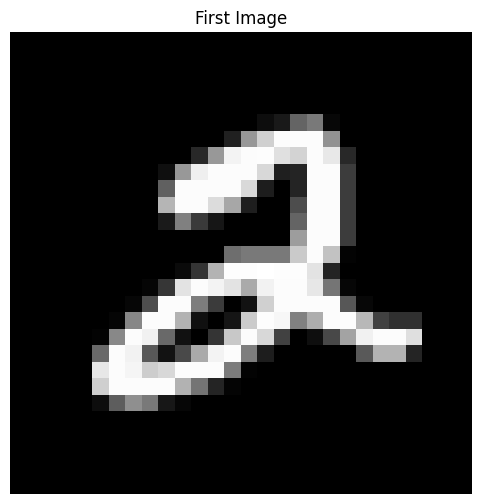

In [2]:
first_image = X.iloc[5].values.reshape(28, 28)

plt.figure(figsize=(6, 6))
plt.imshow(first_image, cmap='gray')
plt.title('First Image')
plt.axis('off')
plt.show()


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [15]:
ss = StandardScaler()
X_train_scale = ss.fit_transform(X_train)
X_test_scale = ss.transform(X_test)


In [16]:
from sklearn.svm import SVC

svm_tune = SVC(random_state=42)

In [17]:
X_train_small, _, y_train_small, _ = train_test_split(
    X_train_scale,
    y_train,
    train_size=5000,
    stratify=y_train,
    random_state=42
)

In [7]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.001],
    'kernel': ['rbf']
}

In [18]:
random_search = RandomizedSearchCV(
    estimator=svm_tune,
    param_distributions=param_grid,
    n_iter=3,
    cv=2,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

In [19]:
print(random_search.estimator)

SVC(random_state=42)


In [20]:
random_search.fit(X_train_small, y_train_small)

Fitting 2 folds for each of 3 candidates, totalling 6 fits


RandomizedSearchCV(cv=2, estimator=SVC(random_state=42), n_iter=3, n_jobs=-1,
                   param_distributions={'C': [0.1, 1, 10, 100],
                                        'gamma': ['scale', 'auto', 0.01, 0.001],
                                        'kernel': ['rbf']},
                   random_state=42, scoring='accuracy', verbose=2)

In [21]:
print("best params: ", random_search.best_params_)
print("best C-Val score: ",random_search.best_score_)

best params:  {'kernel': 'rbf', 'gamma': 'auto', 'C': 1}
best C-Val score:  0.9072


In [22]:
best_svm = SVC(
    kernel='rbf',
    gamma='auto',
    C=1,
    random_state=42
)

best_svm.fit(X_train_scale, y_train)

SVC(C=1, gamma='auto', random_state=42)

In [23]:
y_pred = best_svm.predict(X_test_scale)

from sklearn.metrics import accuracy_score

print("Test Accuracy:", accuracy_score(y_test, y_pred))

Test Accuracy: 0.9637857142857142


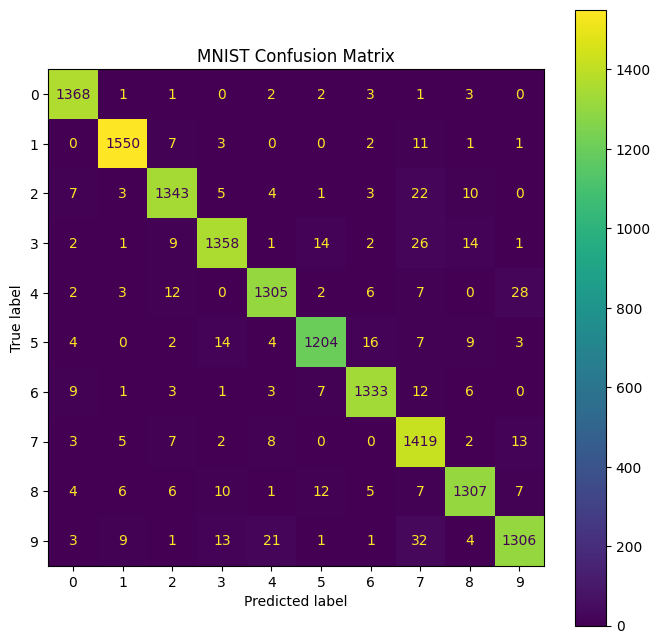

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=range(10)  # digits 0-9 for MNIST
)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax)

plt.title("MNIST Confusion Matrix")
plt.show()

In [26]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred, average='weighted')
print("F1 Score (weighted):", f1)

F1 Score (weighted): 0.9638016938082483
